In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.vapour_reactor_utils import plot_reactor_solutions

from coupled.vapour_reactor import VapourReactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [3]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["HeatPipe"]["material"]["h_cond"] = 550

In [4]:
cfg = generate_config(data, *(15, 60, 40))

print("Fuel pin mesh:")
print("N_R    =", cfg.FP.mesh.N_R)
print("N_fuel =", cfg.FP.mesh.N_fuel)
print("N_gap  =", cfg.FP.mesh.N_gap)
print("N_wall =", cfg.FP.mesh.N_wall)
print("sum    =", cfg.FP.mesh.N_fuel + cfg.FP.mesh.N_gap + cfg.FP.mesh.N_wall)

Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Fuel pin mesh:
N_R    = 60
N_fuel = 52
N_gap  = 2
N_wall = 6
sum    = 60


In [5]:
Ns1 = [15, 7, 40]
Ns2 = [15, 12, 40]
Ns3 = [15, 43, 40]
cfg1 = generate_config(data, *Ns1)
cfg2 = generate_config(data, *Ns2)
cfg3 = generate_config(data, *Ns3)

reactor1 = VapourReactor(cfg1)
reactor2 = VapourReactor(cfg2)
reactor3 = VapourReactor(cfg3)

Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30


In [6]:
solver = Solver([reactor1, reactor2, reactor3])
solver.fsolve()

Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 1 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 2 ...
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running case 3 ...
fsolve message: The solution converged.


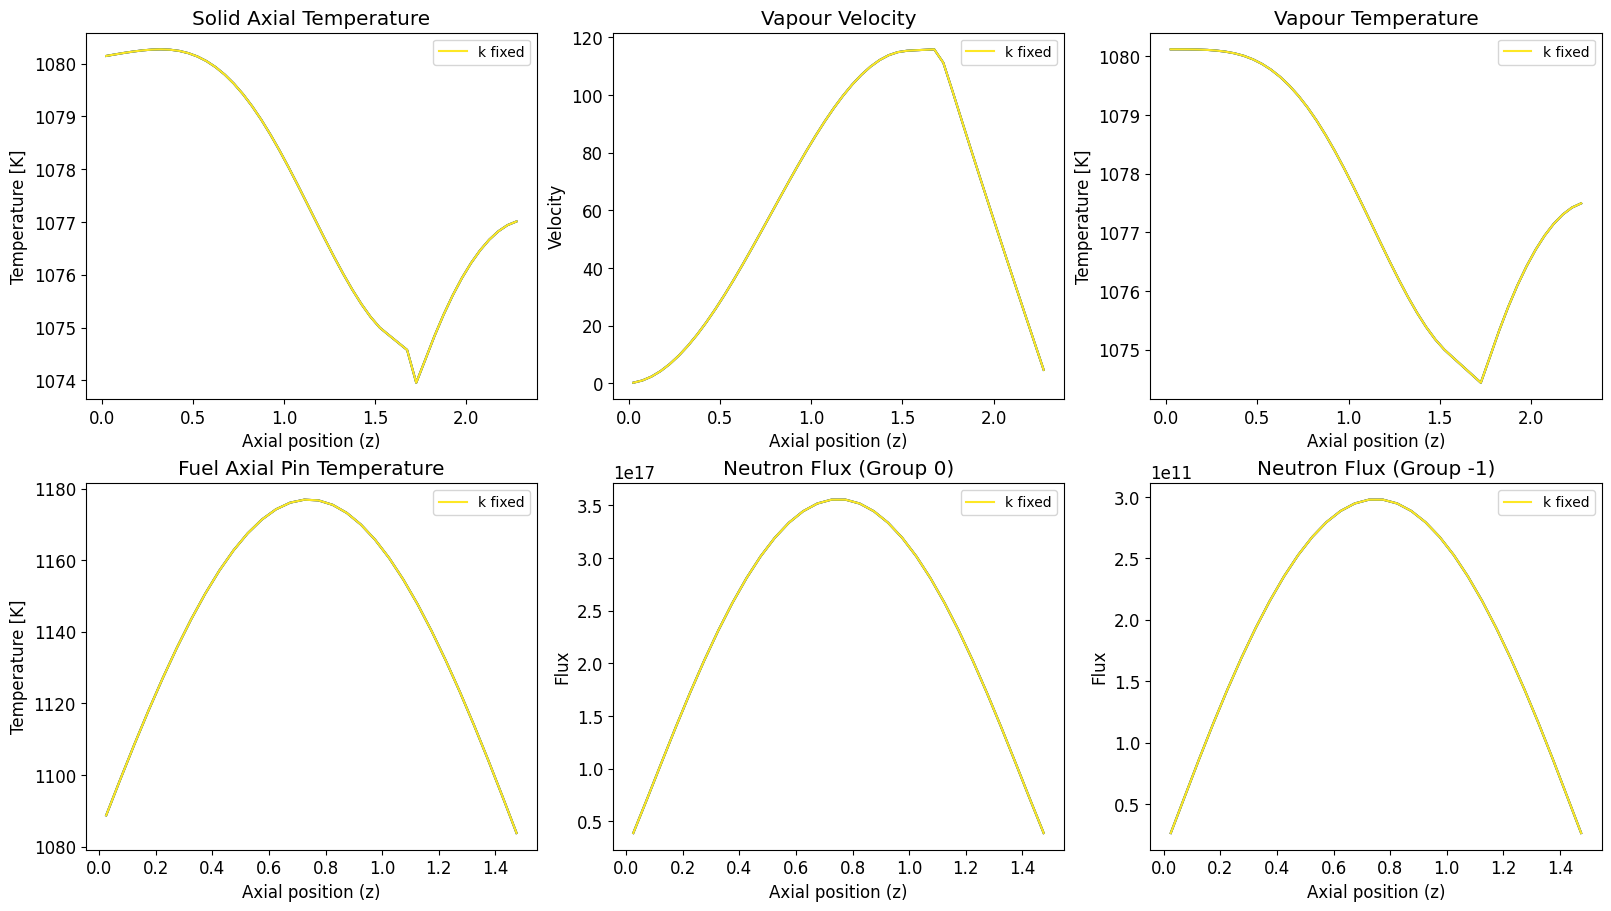

In [7]:
plot_reactor_solutions(solver)

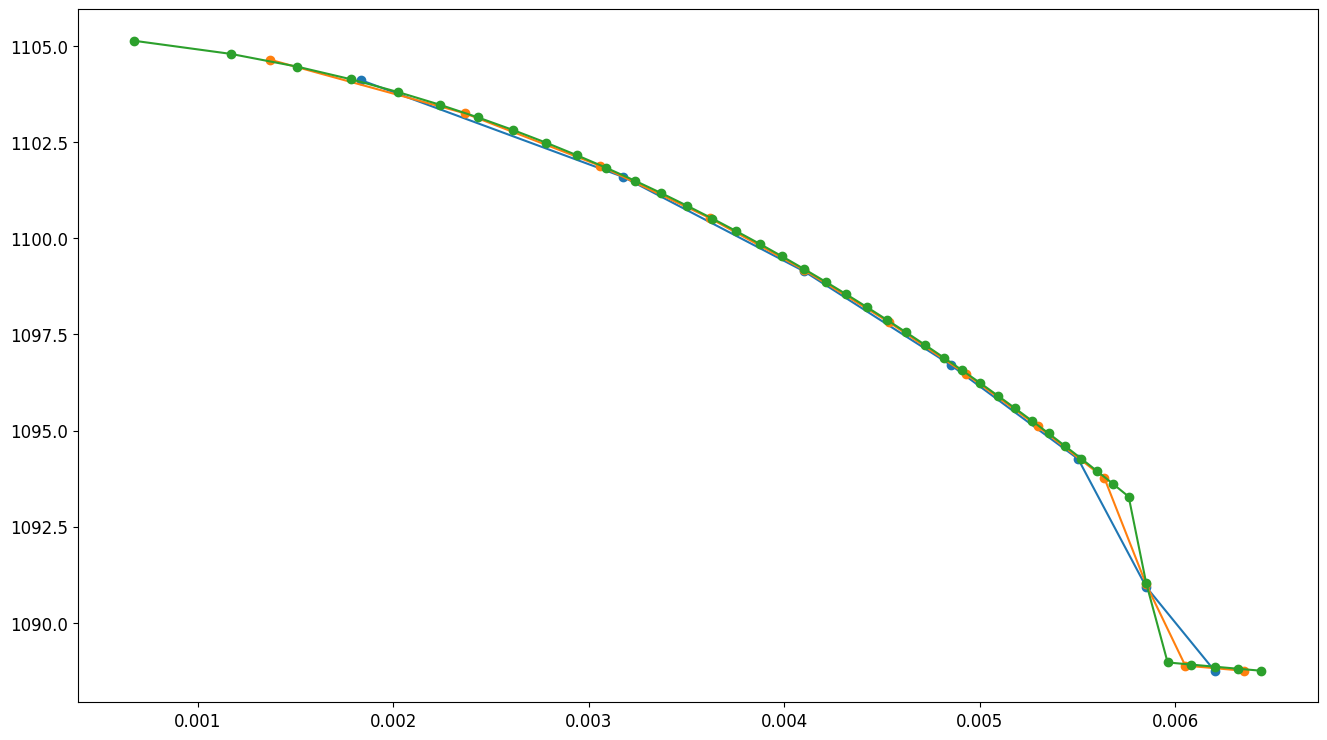

In [14]:
r1 = reactor1.fuel_pin_thermal_model.R
r2 = reactor2.fuel_pin_thermal_model.R
r3 = reactor3.fuel_pin_thermal_model.R

plt.figure(figsize=(16, 9))
plt.plot(r1, solver.solutions[0][1][0, :], "-o")
plt.plot(r2, solver.solutions[1][1][0, :], "-o")
plt.plot(r3, solver.solutions[2][1][0, :], "-o")
plt.show()